In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

## Carga dataset

In [ ]:
df_crimes = pd.read_csv("../datasets/chicago_crimes_and_stations_2024_processed_outliers_encoded.csv")
test_df_crimes = pd.read_csv("../datasets/chicago_crimes_and_stations_2024_processed_outliers_encoded_test.csv")
df_crimes.head()

columns_to_drop = ['Arrest_tag', 'Unnamed: 0']
# Del análiss de selección de features
location_features_to_drop = ['Ward', 'Latitude', 'Longitude', 'Nearest_Police_Station_District_Name_freq', 
                             'Community Area', 'Crime_District_freq', 'Nearest_Police_Station_District_freq']
X_train_final = df_crimes.drop(columns=columns_to_drop+location_features_to_drop)
y_train_encoded = df_crimes['Arrest_tag']


X_test_final = test_df_crimes.drop(columns=columns_to_drop+location_features_to_drop)
y_test_encoded = test_df_crimes['Arrest_tag']

Index(['Beat', 'X Coordinate', 'Y Coordinate',
       'Distance Crime To Police Station', 'Day_sin', 'Season_Spring',
       'Season_Summer', 'Season_Winter', 'Day Time_Early Morning',
       'Day Time_Morning', 'Day Time_Night', 'Domestic_tag', 'IUCR_freq',
       'Primary_Type_freq', 'Location_Description_freq', 'FBI_Code_freq'],
      dtype='object')

## PCA - Reducción Dimensional sobre TODAS las Features

In [4]:
# 1. INFORMACIÓN INICIAL

print("=== DATASET ORIGINAL ===")
print(f"Train shape: {X_train_final.shape}")
print(f"Test shape: {X_test_final.shape}")
print(f"\nFeatures ({X_train_final.shape[1]}): {X_train_final.columns.tolist()}")

=== DATASET ORIGINAL ===
Train shape: (203517, 16)
Test shape: (51503, 16)

Features (16): ['Beat', 'X Coordinate', 'Y Coordinate', 'Distance Crime To Police Station', 'Day_sin', 'Season_Spring', 'Season_Summer', 'Season_Winter', 'Day Time_Early Morning', 'Day Time_Morning', 'Day Time_Night', 'Domestic_tag', 'IUCR_freq', 'Primary_Type_freq', 'Location_Description_freq', 'FBI_Code_freq']


In [5]:
# 2. ESTANDARIZAR TODAS LAS FEATURES (CRUCIAL PARA PCA)
# Fit en train, transform en ambos (evita data leakage)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

print(f"\n=== ESTANDARIZACIÓN ===")
print(f"Train scaled shape: {X_train_scaled.shape}")
print(f"Test scaled shape: {X_test_scaled.shape}")



=== ESTANDARIZACIÓN ===
Train scaled shape: (203517, 16)
Test scaled shape: (51503, 16)


In [7]:
# 3. APLICAR PCA CON TODOS LOS COMPONENTES
# Para analizar varianza explicada

pca_full = PCA()
pca_full.fit(X_train_scaled)

# Calcular varianza explicada acumulada
variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(variance_ratio)

print(f"\n=== VARIANZA POR COMPONENTE ===")
for i, (var, cum_var) in enumerate(zip(variance_ratio, cumulative_variance)):
    print(f"PC{i+1}: {var*100:.2f}% (Acumulada: {cum_var*100:.2f}%)")


=== VARIANZA POR COMPONENTE ===
PC1: 15.70% (Acumulada: 15.70%)
PC2: 13.44% (Acumulada: 29.14%)
PC3: 8.57% (Acumulada: 37.71%)
PC4: 8.41% (Acumulada: 46.12%)
PC5: 8.19% (Acumulada: 54.31%)
PC6: 8.05% (Acumulada: 62.36%)
PC7: 7.00% (Acumulada: 69.36%)
PC8: 6.35% (Acumulada: 75.71%)
PC9: 6.15% (Acumulada: 81.87%)
PC10: 5.45% (Acumulada: 87.31%)
PC11: 2.91% (Acumulada: 90.22%)
PC12: 2.55% (Acumulada: 92.78%)
PC13: 2.39% (Acumulada: 95.17%)
PC14: 2.18% (Acumulada: 97.35%)
PC15: 2.10% (Acumulada: 99.45%)
PC16: 0.55% (Acumulada: 100.00%)


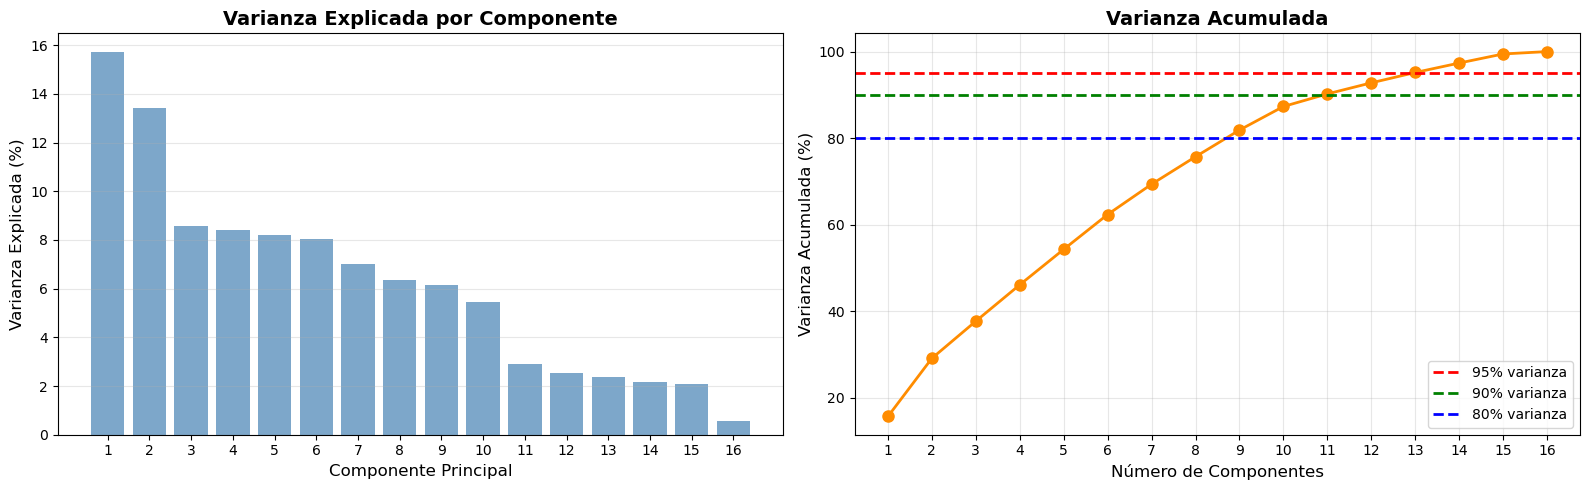

In [8]:
# 4. VISUALIZAR VARIANZA EXPLICADA

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Varianza por componente
ax1.bar(range(1, len(variance_ratio)+1), variance_ratio*100, alpha=0.7, color='steelblue')
ax1.set_xlabel('Componente Principal', fontsize=12)
ax1.set_ylabel('Varianza Explicada (%)', fontsize=12)
ax1.set_title('Varianza Explicada por Componente', fontsize=14, fontweight='bold')
ax1.set_xticks(range(1, len(variance_ratio)+1))
ax1.grid(axis='y', alpha=0.3)

# Gráfico 2: Varianza acumulada
ax2.plot(range(1, len(cumulative_variance)+1), cumulative_variance*100,
         marker='o', linewidth=2, markersize=8, color='darkorange')
ax2.axhline(y=95, color='red', linestyle='--', linewidth=2, label='95% varianza')
ax2.axhline(y=90, color='green', linestyle='--', linewidth=2, label='90% varianza')
ax2.axhline(y=80, color='blue', linestyle='--', linewidth=2, label='80% varianza')
ax2.set_xlabel('Número de Componentes', fontsize=12)
ax2.set_ylabel('Varianza Acumulada (%)', fontsize=12)
ax2.set_title('Varianza Acumulada', fontsize=14, fontweight='bold')
ax2.set_xticks(range(1, len(cumulative_variance)+1))
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# 5. SELECCIONAR NÚMERO ÓPTIMO DE COMPONENTES

n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1

print(f"\n=== OPCIONES DE COMPONENTES ===")
print(f"Componentes para 80% varianza: {n_components_80}")
print(f"Componentes para 90% varianza: {n_components_90}")
print(f"Componentes para 95% varianza: {n_components_95}")
print(f"\nRECOMENDACIÓN: Usar {n_components_95} componentes (95% varianza)")
print(f"   Balance entre reducción ({X_train_final.shape[1]} → {n_components_95}) y retención de info")


=== OPCIONES DE COMPONENTES ===
Componentes para 80% varianza: 9
Componentes para 90% varianza: 11
Componentes para 95% varianza: 13

RECOMENDACIÓN: Usar 13 componentes (95% varianza)
   Balance entre reducción (16 → 13) y retención de info


In [ ]:

# 6. APLICAR PCA FINAL CON COMPONENTES SELECCIONADOS

# Puedes cambiar esto según lo que prefieras:
# n_components_final = n_components_80  # Más agresivo (menos componentes)
# n_components_final = n_components_90  # Intermedio
n_components_final = n_components_95    # Conservador (más componentes)

pca = PCA(n_components=n_components_final)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"\n=== TRANSFORMACIÓN FINAL ===")
print(f"Dimensiones originales: {X_train_final.shape[1]} features")
print(f"Dimensiones PCA: {X_train_pca.shape[1]} componentes")
print(f"Varianza capturada: {pca.explained_variance_ratio_.sum()*100:.2f}%")
print(f"Reducción dimensional: {X_train_final.shape[1] - X_train_pca.shape[1]} features eliminadas")
print(f"Porcentaje de reducción: {(1 - X_train_pca.shape[1]/X_train_final.shape[1])*100:.1f}%")


# 7. CREAR DATAFRAMES CON COMPONENTES PRINCIPALES

pca_columns = [f'PC{i+1}' for i in range(n_components_final)]

X_train_pca_df = pd.DataFrame(X_train_pca,
                               columns=pca_columns,
                               index=X_train_final.index)

X_test_pca_df = pd.DataFrame(X_test_pca,
                              columns=pca_columns,
                              index=X_test_final.index)

print(f"\n=== DATASETS FINALES CON PCA ===")
print(f"X_train_pca_df shape: {X_train_pca_df.shape}")
print(f"X_test_pca_df shape: {X_test_pca_df.shape}")
print(f"\nColumnas: {X_train_pca_df.columns.tolist()}")


# 8. INTERPRETAR COMPONENTES PRINCIPALES
# Ver qué features originales contribuyen más a cada componente

print(f"\n=== INTERPRETACIÓN DE COMPONENTES PRINCIPALES ===")
print("(Contribución de features originales a cada PC)\n")

components_df = pd.DataFrame(
    pca.components_.T,
    columns=pca_columns,
    index=X_train_final.columns
)

# Mostrar top 5 features por componente
for i, pc in enumerate(pca_columns[:5]):  # Mostrar solo primeros 5 PCs
    print(f"\n{pc} (explica {pca.explained_variance_ratio_[i]*100:.2f}% de varianza):")
    print("  Top 5 features con mayor contribución:")
    
    contributions = components_df[pc].abs().sort_values(ascending=False).head(5)
    for feature, abs_value in contributions.items():
        sign = '+' if components_df.loc[feature, pc] > 0 else '-'
        actual_value = components_df.loc[feature, pc]
        print(f"    {sign} {feature:45s}: {abs(actual_value):.3f}")


# 9. HEATMAP DE CONTRIBUCIONES

fig, ax = plt.subplots(figsize=(14, 10))

# Mostrar solo primeros componentes si hay muchos
n_components_to_show = min(10, n_components_final)
components_to_plot = components_df.iloc[:, :n_components_to_show]

sns.heatmap(components_to_plot,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            vmin=-1,
            vmax=1,
            cbar_kws={'label': 'Contribución'},
            linewidths=0.5)

ax.set_xlabel('Componentes Principales', fontsize=12)
ax.set_ylabel('Features Originales', fontsize=12)
ax.set_title(f'Contribución de Features a Primeros {n_components_to_show} Componentes Principales',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


# 10. GRÁFICO DE BARRAS DE CONTRIBUCIONES (primeros 3 componentes)

if n_components_final >= 3:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    for i, (pc, ax) in enumerate(zip(pca_columns[:3], axes)):
        contributions = components_df[pc].abs().sort_values(ascending=False)
        
        colors = ['green' if components_df.loc[feat, pc] > 0 else 'red' 
                  for feat in contributions.index]
        
        ax.barh(contributions.index, contributions.values, color=colors, alpha=0.7)
        ax.set_xlabel('Contribución Absoluta', fontsize=10)
        ax.set_title(f'{pc} ({pca.explained_variance_ratio_[i]*100:.1f}% varianza)',
                     fontsize=12, fontweight='bold')
        ax.invert_yaxis()
        ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()


# 11. ANÁLISIS DE CORRELACIÓN ENTRE PCs (deben ser 0)

pca_corr = X_train_pca_df.corr()
print(f"\n=== VERIFICACIÓN: CORRELACIÓN ENTRE COMPONENTES ===")
print("(Deben ser prácticamente 0 - componentes ortogonales)")
print(f"\nCorrelación máxima entre PCs: {pca_corr.abs().values[np.triu_indices_from(pca_corr.values, k=1)].max():.6f}")
print(f"(Valores cercanos a 0 confirman que PCA funcionó correctamente)")


# 12. GUARDAR DATASETS Y OBJETOS (OPCIONAL)

# Descomentar para guardar:
# X_train_pca_df.to_csv("../datasets/X_train_pca.csv", index=False)
# X_test_pca_df.to_csv("../datasets/X_test_pca.csv", index=False)

# Guardar objetos para reutilizar
# import pickle
# with open("../models/pca_scaler.pkl", "wb") as f:
#     pickle.dump({'pca': pca, 'scaler': scaler}, f)
# print("\n✓ Datasets y objetos guardados!")

print("\n" + "="*60)
print("PCA COMPLETADO EXITOSAMENTE")
print("="*60)
print(f"Reducción: {X_train_final.shape[1]} → {n_components_final} features")
print(f"Varianza retenida: {pca.explained_variance_ratio_.sum()*100:.2f}%")
print(f"\nDatasets listos para modelado:")
print(f"  - X_train_pca_df: {X_train_pca_df.shape}")
print(f"  - X_test_pca_df: {X_test_pca_df.shape}")


In [ ]:
# 1. INFORMACIÓN INICIAL

print("=== DATASET ORIGINAL ===")
print(f"Train shape: {X_train_final.shape}")
print(f"Test shape: {X_test_final.shape}")
print(f"\nFeatures ({X_train_final.shape[1]}): {X_train_final.columns.tolist()}")


# 2. ESTANDARIZAR TODAS LAS FEATURES (CRUCIAL PARA PCA)
# Fit en train, transform en ambos (evita data leakage)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

print(f"\n=== ESTANDARIZACIÓN ===")
print(f"Train scaled shape: {X_train_scaled.shape}")
print(f"Test scaled shape: {X_test_scaled.shape}")


# 3. APLICAR PCA CON TODOS LOS COMPONENTES
# Para analizar varianza explicada

pca_full = PCA()
pca_full.fit(X_train_scaled)

# Calcular varianza explicada acumulada
variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(variance_ratio)

print(f"\n=== VARIANZA EXPLICADA POR COMPONENTE ===")
for i, (var, cum_var) in enumerate(zip(variance_ratio, cumulative_variance)):
    print(f"PC{i+1}: {var*100:.2f}% (Acumulada: {cum_var*100:.2f}%)")


# 4. VISUALIZAR VARIANZA EXPLICADA

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Varianza por componente
ax1.bar(range(1, len(variance_ratio)+1), variance_ratio*100, alpha=0.7, color='steelblue')
ax1.set_xlabel('Componente Principal', fontsize=12)
ax1.set_ylabel('Varianza Explicada (%)', fontsize=12)
ax1.set_title('Varianza Explicada por Componente', fontsize=14, fontweight='bold')
ax1.set_xticks(range(1, len(variance_ratio)+1))
ax1.grid(axis='y', alpha=0.3)

# Gráfico 2: Varianza acumulada
ax2.plot(range(1, len(cumulative_variance)+1), cumulative_variance*100,
         marker='o', linewidth=2, markersize=8, color='darkorange')
ax2.axhline(y=95, color='red', linestyle='--', linewidth=2, label='95% varianza')
ax2.axhline(y=90, color='green', linestyle='--', linewidth=2, label='90% varianza')
ax2.axhline(y=80, color='blue', linestyle='--', linewidth=2, label='80% varianza')
ax2.set_xlabel('Número de Componentes', fontsize=12)
ax2.set_ylabel('Varianza Acumulada (%)', fontsize=12)
ax2.set_title('Varianza Acumulada', fontsize=14, fontweight='bold')
ax2.set_xticks(range(1, len(cumulative_variance)+1))
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# 5. SELECCIONAR NÚMERO ÓPTIMO DE COMPONENTES

n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1

print(f"\n=== OPCIONES DE COMPONENTES ===")
print(f"Componentes para 80% varianza: {n_components_80}")
print(f"Componentes para 90% varianza: {n_components_90}")
print(f"Componentes para 95% varianza: {n_components_95}")
print(f"\nRECOMENDACIÓN: Usar {n_components_95} componentes (95% varianza)")
print(f"   Balance entre reducción ({X_train_final.shape[1]} → {n_components_95}) y retención de info")


# 6. APLICAR PCA FINAL CON COMPONENTES SELECCIONADOS

# Puedes cambiar esto según lo que prefieras:
# n_components_final = n_components_80  # Más agresivo (menos componentes)
# n_components_final = n_components_90  # Intermedio
n_components_final = n_components_95    # Conservador (más componentes)

pca = PCA(n_components=n_components_final)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"\n=== TRANSFORMACIÓN FINAL ===")
print(f"Dimensiones originales: {X_train_final.shape[1]} features")
print(f"Dimensiones PCA: {X_train_pca.shape[1]} componentes")
print(f"Varianza capturada: {pca.explained_variance_ratio_.sum()*100:.2f}%")
print(f"Reducción dimensional: {X_train_final.shape[1] - X_train_pca.shape[1]} features eliminadas")
print(f"Porcentaje de reducción: {(1 - X_train_pca.shape[1]/X_train_final.shape[1])*100:.1f}%")


# 7. CREAR DATAFRAMES CON COMPONENTES PRINCIPALES

pca_columns = [f'PC{i+1}' for i in range(n_components_final)]

X_train_pca_df = pd.DataFrame(X_train_pca,
                               columns=pca_columns,
                               index=X_train_final.index)

X_test_pca_df = pd.DataFrame(X_test_pca,
                              columns=pca_columns,
                              index=X_test_final.index)

print(f"\n=== DATASETS FINALES CON PCA ===")
print(f"X_train_pca_df shape: {X_train_pca_df.shape}")
print(f"X_test_pca_df shape: {X_test_pca_df.shape}")
print(f"\nColumnas: {X_train_pca_df.columns.tolist()}")


# 8. INTERPRETAR COMPONENTES PRINCIPALES
# Ver qué features originales contribuyen más a cada componente

print(f"\n=== INTERPRETACIÓN DE COMPONENTES PRINCIPALES ===")
print("(Contribución de features originales a cada PC)\n")

components_df = pd.DataFrame(
    pca.components_.T,
    columns=pca_columns,
    index=X_train_final.columns
)

# Mostrar top 5 features por componente
for i, pc in enumerate(pca_columns[:5]):  # Mostrar solo primeros 5 PCs
    print(f"\n{pc} (explica {pca.explained_variance_ratio_[i]*100:.2f}% de varianza):")
    print("  Top 5 features con mayor contribución:")
    
    contributions = components_df[pc].abs().sort_values(ascending=False).head(5)
    for feature, abs_value in contributions.items():
        sign = '+' if components_df.loc[feature, pc] > 0 else '-'
        actual_value = components_df.loc[feature, pc]
        print(f"    {sign} {feature:45s}: {abs(actual_value):.3f}")


# 9. HEATMAP DE CONTRIBUCIONES

fig, ax = plt.subplots(figsize=(14, 10))

# Mostrar solo primeros componentes si hay muchos
n_components_to_show = min(10, n_components_final)
components_to_plot = components_df.iloc[:, :n_components_to_show]

sns.heatmap(components_to_plot,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            vmin=-1,
            vmax=1,
            cbar_kws={'label': 'Contribución'},
            linewidths=0.5)

ax.set_xlabel('Componentes Principales', fontsize=12)
ax.set_ylabel('Features Originales', fontsize=12)
ax.set_title(f'Contribución de Features a Primeros {n_components_to_show} Componentes Principales',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


# 10. GRÁFICO DE BARRAS DE CONTRIBUCIONES (primeros 3 componentes)

if n_components_final >= 3:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    for i, (pc, ax) in enumerate(zip(pca_columns[:3], axes)):
        contributions = components_df[pc].abs().sort_values(ascending=False)
        
        colors = ['green' if components_df.loc[feat, pc] > 0 else 'red' 
                  for feat in contributions.index]
        
        ax.barh(contributions.index, contributions.values, color=colors, alpha=0.7)
        ax.set_xlabel('Contribución Absoluta', fontsize=10)
        ax.set_title(f'{pc} ({pca.explained_variance_ratio_[i]*100:.1f}% varianza)',
                     fontsize=12, fontweight='bold')
        ax.invert_yaxis()
        ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()


# 11. ANÁLISIS DE CORRELACIÓN ENTRE PCs (deben ser 0)

pca_corr = X_train_pca_df.corr()
print(f"\n=== VERIFICACIÓN: CORRELACIÓN ENTRE COMPONENTES ===")
print("(Deben ser prácticamente 0 - componentes ortogonales)")
print(f"\nCorrelación máxima entre PCs: {pca_corr.abs().values[np.triu_indices_from(pca_corr.values, k=1)].max():.6f}")
print(f"(Valores cercanos a 0 confirman que PCA funcionó correctamente)")


# 12. GUARDAR DATASETS Y OBJETOS (OPCIONAL)

# Descomentar para guardar:
# X_train_pca_df.to_csv("../datasets/X_train_pca.csv", index=False)
# X_test_pca_df.to_csv("../datasets/X_test_pca.csv", index=False)

# Guardar objetos para reutilizar
# import pickle
# with open("../models/pca_scaler.pkl", "wb") as f:
#     pickle.dump({'pca': pca, 'scaler': scaler}, f)
# print("\n✓ Datasets y objetos guardados!")

print("\n" + "="*60)
print("PCA COMPLETADO EXITOSAMENTE")
print("="*60)
print(f"Reducción: {X_train_final.shape[1]} → {n_components_final} features")
print(f"Varianza retenida: {pca.explained_variance_ratio_.sum()*100:.2f}%")
print(f"\nDatasets listos para modelado:")
print(f"  - X_train_pca_df: {X_train_pca_df.shape}")
print(f"  - X_test_pca_df: {X_test_pca_df.shape}")
